# 🔥 Distributed LLM — Stress Test (1000 Users)
**CSE354 Distributed Computing Project**

Simulates 1000 concurrent users hitting the master API, saves all request/response data to CSV, and produces a full performance report with charts.

**Metrics measured:**
- Latency (avg, min, max, p50, p90, p95, p99)
- Throughput (req/s)
- Success / failure rate
- Worker distribution (load balance quality)
- Scheduler comparison (round_robin vs least_connections vs load_aware)
- Latency over time (how the system behaves under sustained load)
- Error analysis

## Cell 1 — Configuration

In [1]:
# ================================================================
# CONFIGURATION
# ================================================================

MASTER_URL       = "http://13.63.238.244"   # your EC2 master (through NGINX)
REQUEST_TIMEOUT  = 180                       # seconds per request

# ── Load test parameters ────────────────────────────────────────
TOTAL_USERS      = 1000   # total requests to fire
CONCURRENCY      = 50 # simultaneous threads at any one time
                          # (matches master MAX_CONCURRENT_REQUESTS=50)

# Ramp-up: gradually increase concurrency to avoid thundering herd
# Set to 0 to disable ramp-up and fire all at once
RAMP_UP_SECONDS  = 30     # spread first batch over this many seconds

# Output files
CSV_OUTPUT       = "stress_test_results.csv"
REPORT_OUTPUT    = "stress_test_report.txt"

# Run scheduler comparison test?
# Sends COMPARISON_REQUESTS requests under each scheduler and compares
RUN_COMPARISON   = True
COMPARISON_REQUESTS = 30   # per scheduler (keep low — each takes ~10-30s)
COMPARISON_CONCURRENCY = 10

print("=" * 55)
print(f"  Master URL       : {MASTER_URL}")
print(f"  Total users      : {TOTAL_USERS}")
print(f"  Concurrency      : {CONCURRENCY}")
print(f"  Ramp-up          : {RAMP_UP_SECONDS}s")
print(f"  Scheduler compare: {RUN_COMPARISON}")
print("=" * 55)

  Master URL       : http://13.63.238.244
  Total users      : 1000
  Concurrency      : 50
  Ramp-up          : 30s
  Scheduler compare: True


## Cell 2 — Install & Imports

In [2]:
!pip install -q requests pandas matplotlib seaborn numpy tqdm

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import threading
import time
import csv
import os
import json
import random
import math
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
from tqdm.notebook import tqdm

sns.set_theme(style="darkgrid", palette="husl")
plt.rcParams["figure.dpi"] = 120

print("✅ Imports ready")

✅ Imports ready


## Cell 3 — Query Bank (diverse queries for 1000 users)

In [3]:
# 50 varied queries spanning different complexities and domains.
# They are sampled with repetition to generate 1000 unique user requests.

QUERY_BANK = [
    # Distributed systems
    "What is load balancing and why is it important?",
    "Explain the CAP theorem in distributed systems.",
    "How does consistent hashing work?",
    "What is the difference between horizontal and vertical scaling?",
    "Explain the two-phase commit protocol.",
    "What is a distributed hash table?",
    "How does the Raft consensus algorithm work?",
    "What is eventual consistency?",
    "Explain the concept of sharding in databases.",
    "What is a service mesh?",
    # Fault tolerance
    "How does a circuit breaker pattern work?",
    "What is the difference between failover and failback?",
    "Explain Byzantine fault tolerance.",
    "What is a heartbeat mechanism in distributed systems?",
    "How does leader election work in distributed systems?",
    "What is a dead letter queue?",
    "Explain graceful degradation in software systems.",
    "What is chaos engineering?",
    "How do you detect and handle split-brain scenarios?",
    "What is the difference between active-active and active-passive clustering?",
    # LLM and AI
    "What is retrieval-augmented generation (RAG)?",
    "How does FAISS enable fast vector search?",
    "What is the difference between fine-tuning and RAG?",
    "Explain transformer attention mechanisms.",
    "What is quantization in LLM deployment?",
    "How does Ollama serve LLMs locally?",
    "What is tensor parallelism in GPU computing?",
    "Explain the concept of token generation in LLMs.",
    "What is a vector embedding?",
    "How does semantic search differ from keyword search?",
    # GPU and compute
    "What is CUDA and how does it enable GPU computing?",
    "Explain the difference between data parallelism and model parallelism.",
    "What is GPU memory bandwidth and why does it matter for LLMs?",
    "How does batching improve GPU utilization?",
    "What is the difference between FP16 and FP32 in GPU computing?",
    # Scheduling
    "Compare round-robin and least-connections load balancing.",
    "What is weighted round-robin scheduling?",
    "Explain priority queue scheduling.",
    "What is the difference between preemptive and non-preemptive scheduling?",
    "How does dynamic load-aware routing improve performance?",
    # Networking
    "What is the role of NGINX in a distributed system?",
    "Explain HTTP keep-alive connections.",
    "What is a reverse proxy?",
    "How does ngrok create secure tunnels?",
    "What is the difference between TCP and UDP for distributed systems?",
    # Cloud
    "What is AWS EC2 and how is it used for distributed computing?",
    "Explain auto-scaling in cloud environments.",
    "What is a VPC in AWS?",
    "How do security groups work in AWS EC2?",
    "What is the difference between EC2 and Lambda for running Python services?",
]

def generate_user_queries(n: int) -> list:
    """Generate n queries by sampling from the query bank with slight variation."""
    queries = []
    for i in range(n):
        base = QUERY_BANK[i % len(QUERY_BANK)]
        # Add user ID variation so identical base queries look different
        queries.append({"user_id": i + 1, "query": base})
    random.shuffle(queries)
    return queries

USER_QUERIES = generate_user_queries(TOTAL_USERS)
print(f"✅ Generated {len(USER_QUERIES)} user queries from {len(QUERY_BANK)} templates")
print(f"   Sample: {USER_QUERIES[0]}")

✅ Generated 1000 user queries from 50 templates
   Sample: {'user_id': 657, 'query': 'How does the Raft consensus algorithm work?'}


## Cell 4 — Core Request Function & CSV Writer

In [4]:
# ── Thread-safe CSV writer ──────────────────────────────────────────────────
CSV_LOCK    = threading.Lock()
CSV_FIELDS  = [
    "request_id", "user_id", "query", "timestamp_start", "timestamp_end",
    "latency_s", "status", "http_status", "selected_worker", "scheduler",
    "attempts", "worker_latency_s", "response_preview", "error"
]

def init_csv(path: str):
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_FIELDS)
        writer.writeheader()

def append_csv(path: str, row: dict):
    with CSV_LOCK:
        with open(path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=CSV_FIELDS)
            writer.writerow(row)


# ── Single request function ─────────────────────────────────────────────────
def send_request(request_id: int, user_id: int, query: str,
                 csv_path: str, master_url: str) -> dict:
    """
    Send one request to the master, record all timing and metadata,
    append to CSV, and return the result dict.
    """
    ts_start = time.time()
    dt_start = datetime.utcfromtimestamp(ts_start).isoformat()

    result = {
        "request_id"       : request_id,
        "user_id"          : user_id,
        "query"            : query,
        "timestamp_start"  : dt_start,
        "timestamp_end"    : "",
        "latency_s"        : None,
        "status"           : "error",
        "http_status"      : None,
        "selected_worker"  : "",
        "scheduler"        : "",
        "attempts"         : None,
        "worker_latency_s" : None,
        "response_preview" : "",
        "error"            : "",
    }

    try:
        resp = requests.post(
            f"{master_url}/submit_task",
            json={"query": query},
            timeout=REQUEST_TIMEOUT
        )
        ts_end    = time.time()
        latency_s = round(ts_end - ts_start, 3)

        result["timestamp_end"] = datetime.utcfromtimestamp(ts_end).isoformat()
        result["latency_s"]     = latency_s
        result["http_status"]   = resp.status_code

        if resp.status_code == 200:
            data = resp.json()
            result["scheduler"]       = data.get("scheduler", "")
            result["selected_worker"] = data.get("selected_worker", "")
            result["attempts"]        = data.get("attempts", 1)

            if "error" in data:
                # Master returned 200 but with an application-level error
                result["status"] = "app_error"
                result["error"]  = data["error"]
            else:
                inner = data.get("result", {})
                result["status"]           = "success"
                result["worker_latency_s"] = inner.get("latency_s")
                raw_response               = inner.get("response", "")
                result["response_preview"] = str(raw_response)[:200].replace("\n", " ")
        else:
            result["status"] = "http_error"
            result["error"]  = f"HTTP {resp.status_code}"

    except requests.exceptions.Timeout:
        ts_end = time.time()
        result["latency_s"]     = round(ts_end - ts_start, 3)
        result["timestamp_end"] = datetime.utcfromtimestamp(ts_end).isoformat()
        result["status"]        = "timeout"
        result["error"]         = f"Timeout after {REQUEST_TIMEOUT}s"

    except Exception as e:
        ts_end = time.time()
        result["latency_s"]     = round(ts_end - ts_start, 3)
        result["timestamp_end"] = datetime.utcfromtimestamp(ts_end).isoformat()
        result["status"]        = "error"
        result["error"]         = str(e)[:200]

    append_csv(csv_path, result)
    return result


print("✅ Core request function and CSV writer ready")

✅ Core request function and CSV writer ready


## Cell 5 — Pre-flight Check

In [5]:
print("Running pre-flight checks...\n")

checks = {
    "Master root"    : f"{MASTER_URL}/",
    "Master health"  : f"{MASTER_URL}/health",
    "Master workers" : f"{MASTER_URL}/workers",
    "Master metrics" : f"{MASTER_URL}/metrics",
}

all_ok = True
for name, url in checks.items():
    try:
        r = requests.get(url, timeout=8)
        data = r.json()
        print(f"  ✅ {name:20s}  {r.status_code}  {str(data)[:80]}")
    except Exception as e:
        print(f"  ❌ {name:20s}  {e}")
        all_ok = False

# Show alive workers
try:
    workers = requests.get(f"{MASTER_URL}/workers", timeout=8).json()
    alive   = [w for w, d in workers.items() if d["alive"]]
    dead    = [w for w, d in workers.items() if not d["alive"]]
    print(f"\n  Alive workers  : {alive}")
    print(f"  Dead workers   : {dead}")
    if not alive:
        print("  ⚠️  WARNING: No alive workers — stress test will fail")
        all_ok = False
except Exception as e:
    print(f"  Could not fetch workers: {e}")

print(f"\n{'✅ System ready for stress test' if all_ok else '❌ Fix issues above before running'}")

Running pre-flight checks...

  ✅ Master root           200  {'service': 'Distributed LLM Master', 'version': '3.0', 'scheduler': 'load_aware
  ✅ Master health         200  {'status': 'ok', 'alive_workers': 8, 'scheduler': 'load_aware'}
  ✅ Master workers        200  {'abdooo1-worker-2': {'worker_url': 'https://thus-closer-exceptions-carbon.trycl
  ✅ Master metrics        200  {'workers_total': 13, 'workers_alive': 8, 'workers_dead': 5, 'requests_received'

  Alive workers  : ['gpu-worker-2', 'gpu-worker-3', 'lllllllll-worker-2', 'lllllllll-worker-3', 'lllllllll-worker-1', 'vhgghg-worker-1', 'vhgghg-worker-2', 'vhgghg-worker-3']
  Dead workers   : ['abdooo1-worker-2', 'abdooo1-worker-1', 'abdo-worker-2', 'vvvddd-worker-2', 'vvvddd-worker-3']

✅ System ready for stress test


## Cell 6 — 🔥 Main Stress Test (1000 Users)

In [6]:
import math, time, threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

# ── Initialise CSV ─────────────────────────────────────────────────────────────
init_csv(CSV_OUTPUT)
print(f"📄 CSV initialised: {CSV_OUTPUT}")

# ── Shared counters ────────────────────────────────────────────────────────────
counters_lock = threading.Lock()
counters = {"success": 0, "error": 0, "timeout": 0, "app_error": 0}

all_results  = []
results_lock = threading.Lock()

test_start_time = time.time()

# ── Wrapper ────────────────────────────────────────────────────────────────────
def run_request(req_id, user_id, query):
    result = send_request(req_id, user_id, query, CSV_OUTPUT, MASTER_URL)
    with counters_lock:
        s = result["status"]
        counters[s if s in counters else "error"] += 1
    with results_lock:
        all_results.append(result)
    return result

# ── Build wave schedule ────────────────────────────────────────────────────────
def build_schedule(queries, ramp_seconds, concurrency):
    waves = math.ceil(len(queries) / concurrency)
    delay = ramp_seconds / max(waves - 1, 1)
    return [(i // concurrency * delay, q) for i, q in enumerate(queries)]

if RAMP_UP_SECONDS > 0:
    schedule = build_schedule(USER_QUERIES, RAMP_UP_SECONDS, CONCURRENCY)
    print(f"⏱  Ramp-up: {RAMP_UP_SECONDS}s across {math.ceil(TOTAL_USERS / CONCURRENCY)} waves")
else:
    schedule = [(0, q) for q in USER_QUERIES]
    print("⚡ No ramp-up — firing all requests simultaneously")

print(f"🚀 Starting stress test: {TOTAL_USERS} users, concurrency={CONCURRENCY}\n")

pbar = tqdm(total=TOTAL_USERS, desc="Requests", unit="req")

# ── Fire in waves — submit one wave, wait for it, then submit next ─────────────
# This is the KEY fix: we never have more than CONCURRENCY tasks in-flight.
# The old version submitted all 1000 futures at once then slept, which
# bypassed the ramp-up entirely because the pool queued everything immediately.

with ThreadPoolExecutor(max_workers=CONCURRENCY) as pool:
    wave_size   = CONCURRENCY
    total_waves = math.ceil(TOTAL_USERS / wave_size)

    for wave_idx in range(total_waves):
        wave_start = wave_idx * wave_size
        wave_end   = min(wave_start + wave_size, TOTAL_USERS)
        wave_items = schedule[wave_start:wave_end]

        # Ramp-up: wait until this wave's scheduled start time
        if RAMP_UP_SECONDS > 0 and wave_idx > 0:
            target_elapsed = wave_items[0][0]          # delay of first item in wave
            actual_elapsed = time.time() - test_start_time
            sleep_needed   = target_elapsed - actual_elapsed
            if sleep_needed > 0:
                time.sleep(sleep_needed)

        # Submit this wave
        wave_futures = [
            pool.submit(run_request, wave_start + i + 1,
                        item["user_id"], item["query"])
            for i, (_, item) in enumerate(wave_items)
        ]

        # Wait for the entire wave to complete before submitting the next
        for f in as_completed(wave_futures):
            pbar.update(1)
            pbar.set_postfix({
                "ok" : counters["success"],
                "err": counters["error"] + counters["app_error"],
                "to" : counters["timeout"],
                "wave": f"{wave_idx + 1}/{total_waves}",
            })

pbar.close()

test_wall_time = time.time() - test_start_time

print(f"\n{'='*55}")
print(f"  Stress test complete in {test_wall_time:.1f}s")
print(f"  Success  : {counters['success']}")
print(f"  Errors   : {counters['error']}")
print(f"  App err  : {counters['app_error']}")
print(f"  Timeouts : {counters['timeout']}")
print(f"  Throughput: {TOTAL_USERS / test_wall_time:.2f} req/s")
print(f"  CSV saved: {CSV_OUTPUT}")
print(f"{'='*55}")

/home/abdo-bahig/Desktop/stress_test/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📄 CSV initialised: stress_test_results.csv
⏱  Ramp-up: 30s across 20 waves
🚀 Starting stress test: 1000 users, concurrency=50



Requests:   0%|          | 0/1000 [00:00<?, ?req/s]/tmp/ipykernel_16135/1953410249.py:29: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt_start = datetime.utcfromtimestamp(ts_start).isoformat()
/tmp/ipykernel_16135/1953410249.py:57: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  result["timestamp_end"] = datetime.utcfromtimestamp(ts_end).isoformat()
Requests: 100%|██████████| 1000/1000 [06:25<00:00,  2.59req/s, ok=853, err=147, to=0, wave=20/20]


  Stress test complete in 385.7s
  Success  : 853
  Errors   : 147
  App err  : 0
  Timeouts : 0
  Throughput: 2.59 req/s
  CSV saved: stress_test_results.csv


## Cell 7 — Load Results & Compute Performance Metrics

In [7]:
# ── Load CSV ──────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_OUTPUT, parse_dates=["timestamp_start", "timestamp_end"])
print(f"Loaded {len(df)} rows from {CSV_OUTPUT}")
print(f"Columns: {list(df.columns)}\n")

# ── Subset: only successful requests for latency stats ────────────────────────
df_ok = df[df["status"] == "success"].copy()

# ── Core stats ────────────────────────────────────────────────────────────────
total          = len(df)
success_count  = len(df_ok)
error_count    = len(df[df["status"] != "success"])
success_rate   = success_count / total * 100

latencies      = df_ok["latency_s"].dropna()
wall_time      = (df["timestamp_end"].max() - df["timestamp_start"].min()).total_seconds()
throughput     = total / wall_time

pct = lambda q: round(np.percentile(latencies, q), 3) if len(latencies) else None

metrics = {
    "Total requests"      : total,
    "Successful"          : success_count,
    "Failed"              : error_count,
    "Success rate"        : f"{success_rate:.2f}%",
    "Wall time (s)"       : round(wall_time, 2),
    "Throughput (req/s)"  : round(throughput, 3),
    "Latency mean (s)"    : round(latencies.mean(), 3) if len(latencies) else None,
    "Latency median (s)"  : pct(50),
    "Latency p90 (s)"     : pct(90),
    "Latency p95 (s)"     : pct(95),
    "Latency p99 (s)"     : pct(99),
    "Latency min (s)"     : round(latencies.min(), 3) if len(latencies) else None,
    "Latency max (s)"     : round(latencies.max(), 3) if len(latencies) else None,
    "Latency std (s)"     : round(latencies.std(), 3) if len(latencies) else None,
}

# ── Worker distribution ───────────────────────────────────────────────────────
worker_dist = df_ok["selected_worker"].value_counts()

# ── Error breakdown ───────────────────────────────────────────────────────────
error_breakdown = df[df["status"] != "success"]["status"].value_counts().to_dict()

# ── Retry analysis ────────────────────────────────────────────────────────────
if "attempts" in df_ok.columns:
    retry_dist = df_ok["attempts"].value_counts().sort_index().to_dict()
else:
    retry_dist = {}

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 55)
print("  PERFORMANCE METRICS REPORT")
print("=" * 55)
for k, v in metrics.items():
    print(f"  {k:<25s}: {v}")

print(f"\n  WORKER DISTRIBUTION:")
for w, cnt in worker_dist.items():
    bar  = "█" * min(int(cnt / total * 40), 40)
    pct_ = cnt / total * 100
    print(f"    {w:<22s}  {bar:<40s} {cnt:>5} ({pct_:.1f}%)")

print(f"\n  ERROR BREAKDOWN: {error_breakdown}")
print(f"  RETRY DISTRIBUTION: {retry_dist}")
print("=" * 55)

Loaded 1000 rows from stress_test_results.csv
Columns: ['request_id', 'user_id', 'query', 'timestamp_start', 'timestamp_end', 'latency_s', 'status', 'http_status', 'selected_worker', 'scheduler', 'attempts', 'worker_latency_s', 'response_preview', 'error']

  PERFORMANCE METRICS REPORT
  Total requests           : 1000
  Successful               : 853
  Failed                   : 147
  Success rate             : 85.30%
  Wall time (s)            : 385.7
  Throughput (req/s)       : 2.593
  Latency mean (s)         : 9.338
  Latency median (s)       : 8.801
  Latency p90 (s)          : 16.165
  Latency p95 (s)          : 18.197
  Latency p99 (s)          : 21.539
  Latency min (s)          : 1.431
  Latency max (s)          : 27.764
  Latency std (s)          : 4.998

  WORKER DISTRIBUTION:
    gpu-worker-3            ████████                                   213 (21.3%)
    vhgghg-worker-2         ███████                                    193 (19.3%)
    vhgghg-worker-3         █████

## Cell 8 — 📊 Performance Charts

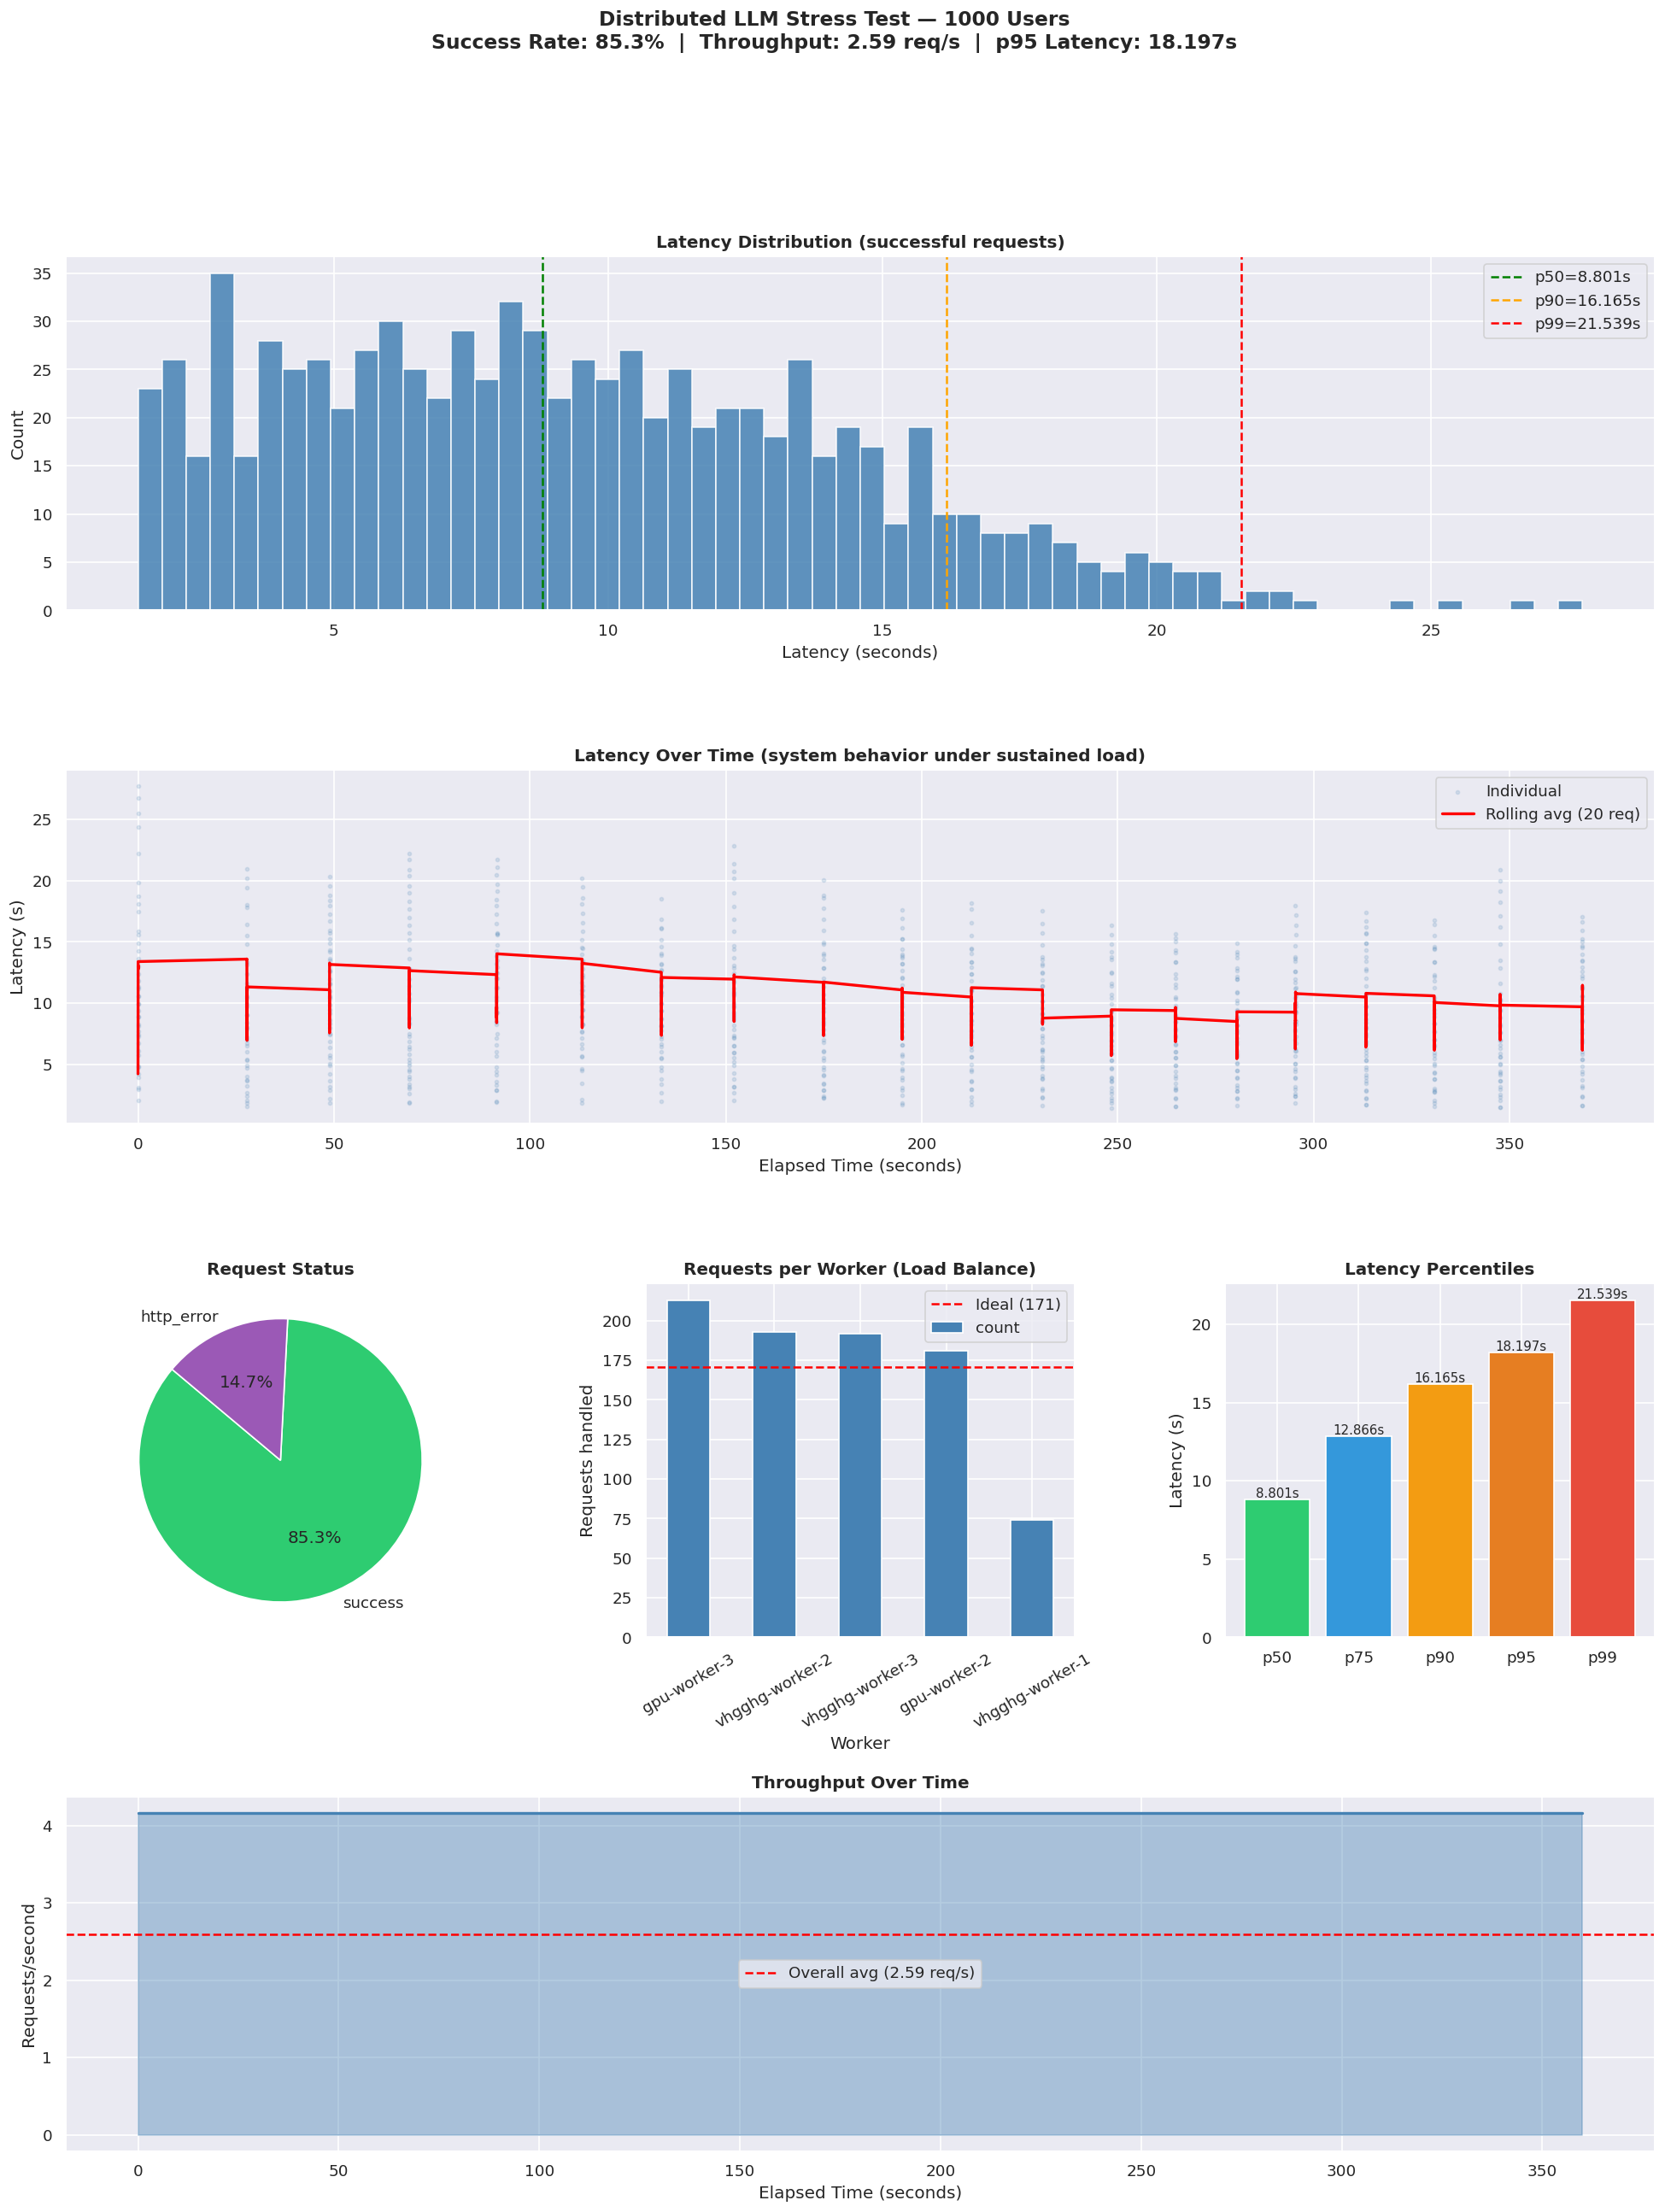

✅ Charts saved: stress_test_charts.png


In [8]:
fig = plt.figure(figsize=(20, 24))
fig.suptitle(
    f"Distributed LLM Stress Test — {total} Users\n"
    f"Success Rate: {success_rate:.1f}%  |  Throughput: {throughput:.2f} req/s  |  "
    f"p95 Latency: {pct(95)}s",
    fontsize=14, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Latency distribution histogram ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.hist(latencies, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
for label, q, color in [("p50", 50, "green"), ("p90", 90, "orange"), ("p99", 99, "red")]:
    val = pct(q)
    ax1.axvline(val, color=color, linestyle="--", linewidth=1.5, label=f"{label}={val}s")
ax1.set_title("Latency Distribution (successful requests)", fontweight="bold")
ax1.set_xlabel("Latency (seconds)")
ax1.set_ylabel("Count")
ax1.legend()

# ── 2. Latency over time (rolling window) ────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
df_ok_sorted = df_ok.sort_values("timestamp_start").copy()
df_ok_sorted["elapsed_s"] = (
    df_ok_sorted["timestamp_start"] - df_ok_sorted["timestamp_start"].min()
).dt.total_seconds()
# Rolling average over 20 requests
df_ok_sorted["rolling_latency"] = df_ok_sorted["latency_s"].rolling(20, min_periods=1).mean()
ax2.scatter(df_ok_sorted["elapsed_s"], df_ok_sorted["latency_s"],
            alpha=0.15, s=6, color="steelblue", label="Individual")
ax2.plot(df_ok_sorted["elapsed_s"], df_ok_sorted["rolling_latency"],
         color="red", linewidth=2, label="Rolling avg (20 req)")
ax2.set_title("Latency Over Time (system behavior under sustained load)", fontweight="bold")
ax2.set_xlabel("Elapsed Time (seconds)")
ax2.set_ylabel("Latency (s)")
ax2.legend()

# ── 3. Success / failure pie ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
status_counts = df["status"].value_counts()
colors = ["#2ecc71" if s == "success" else "#e74c3c" if s == "error"
          else "#f39c12" if s == "timeout" else "#9b59b6"
          for s in status_counts.index]
ax3.pie(status_counts.values, labels=status_counts.index,
        autopct="%1.1f%%", colors=colors, startangle=140)
ax3.set_title("Request Status", fontweight="bold")

# ── 4. Worker distribution bar chart ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
worker_dist.plot(kind="bar", ax=ax4, color="steelblue", edgecolor="white")
ax4.set_title("Requests per Worker (Load Balance)", fontweight="bold")
ax4.set_xlabel("Worker")
ax4.set_ylabel("Requests handled")
ax4.tick_params(axis="x", rotation=30)
# Add ideal line
if len(worker_dist) > 0:
    ideal = success_count / len(worker_dist)
    ax4.axhline(ideal, color="red", linestyle="--", label=f"Ideal ({ideal:.0f})")
    ax4.legend()

# ── 5. Latency percentile bar chart ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 2])
pcts   = [50, 75, 90, 95, 99]
pvals  = [pct(p) for p in pcts]
colors_ = ["#2ecc71", "#3498db", "#f39c12", "#e67e22", "#e74c3c"]
ax5.bar([f"p{p}" for p in pcts], pvals, color=colors_, edgecolor="white")
for i, (bar_label, val) in enumerate(zip(pcts, pvals)):
    ax5.text(i, val + 0.1, f"{val}s", ha="center", fontsize=9)
ax5.set_title("Latency Percentiles", fontweight="bold")
ax5.set_ylabel("Latency (s)")

# ── 6. Throughput over time ───────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, :])
df_sorted = df.sort_values("timestamp_start").copy()
df_sorted["elapsed_s"] = (
    df_sorted["timestamp_start"] - df_sorted["timestamp_start"].min()
).dt.total_seconds()
# Bin into 10s windows and count completions
bin_size = max(int(wall_time / 30), 1)  # ~30 bins
df_sorted["time_bin"] = (df_sorted["elapsed_s"] // bin_size) * bin_size
throughput_over_time  = df_sorted.groupby("time_bin").size() / bin_size
ax6.fill_between(throughput_over_time.index, throughput_over_time.values,
                 alpha=0.4, color="steelblue")
ax6.plot(throughput_over_time.index, throughput_over_time.values,
         color="steelblue", linewidth=2)
ax6.axhline(throughput, color="red", linestyle="--",
            label=f"Overall avg ({throughput:.2f} req/s)")
ax6.set_title("Throughput Over Time", fontweight="bold")
ax6.set_xlabel("Elapsed Time (seconds)")
ax6.set_ylabel("Requests/second")
ax6.legend()

plt.savefig("stress_test_charts.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Charts saved: stress_test_charts.png")

## Cell 9 — Scheduler Comparison Test


🔄 Testing scheduler: round_robin  ({'message': 'scheduler changed to round_robin'})


/tmp/ipykernel_16135/1953410249.py:29: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  dt_start = datetime.utcfromtimestamp(ts_start).isoformat()
round_robin:   0%|          | 0/30 [00:00<?, ?it/s]/tmp/ipykernel_16135/1953410249.py:57: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  result["timestamp_end"] = datetime.utcfromtimestamp(ts_end).isoformat()
round_robin: 100%|██████████| 30/30 [00:12<00:00,  2.35it/s]


  mean=3.30s  p50=3.36s  p95=5.09s  n=30

🔄 Testing scheduler: least_connections  ({'message': 'scheduler changed to least_connections'})


least_connections: 100%|██████████| 30/30 [00:10<00:00,  2.74it/s]


  mean=2.87s  p50=2.88s  p95=3.79s  n=29

🔄 Testing scheduler: load_aware  ({'message': 'scheduler changed to load_aware'})


load_aware: 100%|██████████| 30/30 [00:10<00:00,  2.77it/s]


  mean=3.01s  p50=2.74s  p95=4.55s  n=30

✅ Restored scheduler to load_aware


/tmp/ipykernel_16135/586935175.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_to_plot, labels=SCHEDULERS, patch_artist=True)


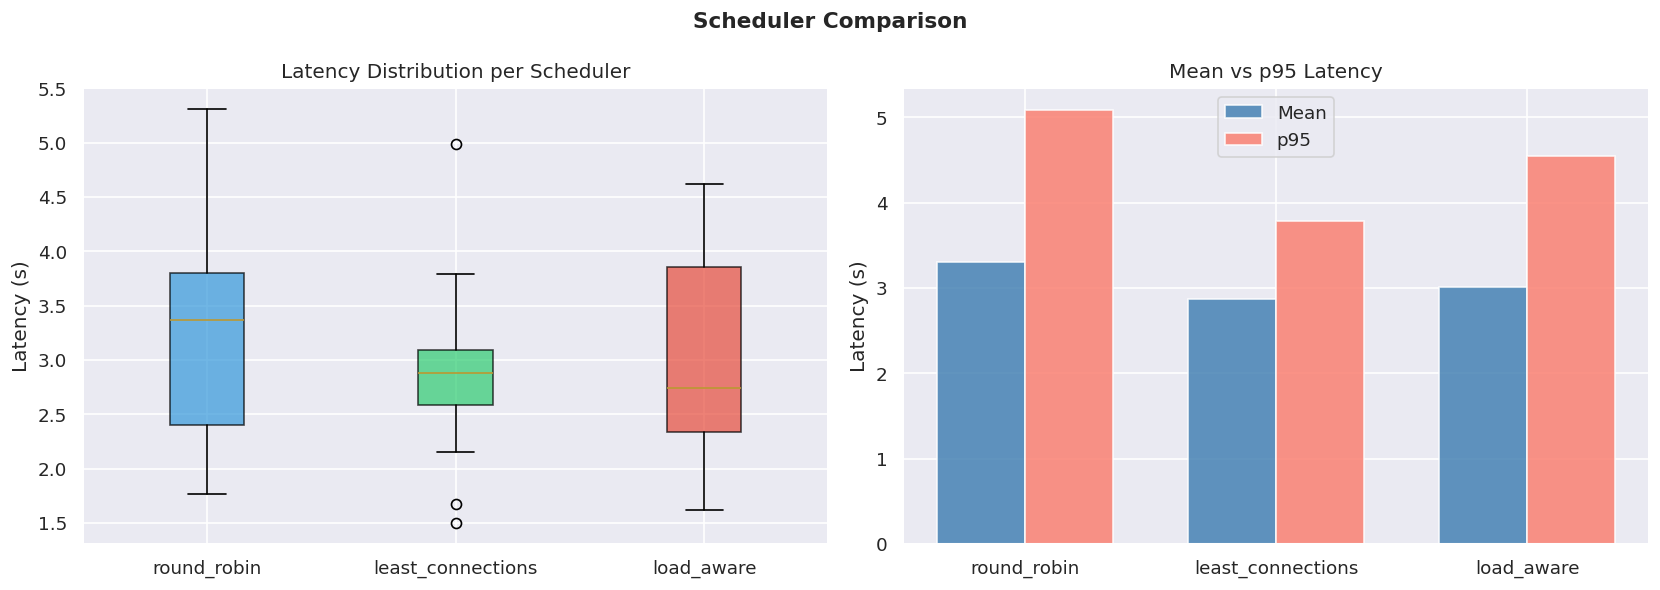

✅ Saved: scheduler_comparison.png


In [9]:
if not RUN_COMPARISON:
    print("Skipping scheduler comparison (RUN_COMPARISON=False)")
else:
    SCHEDULERS = ["round_robin", "least_connections", "load_aware"]
    comparison_results = {}   # scheduler → list of latency values

    for scheduler in SCHEDULERS:
        # Switch master scheduler
        r = requests.post(f"{MASTER_URL}/scheduler/{scheduler}", timeout=8)
        print(f"\n🔄 Testing scheduler: {scheduler}  ({r.json()})")
        time.sleep(2)

        comp_csv   = f"comparison_{scheduler}.csv"
        init_csv(comp_csv)
        comp_latencies = []
        comp_queries = USER_QUERIES[:COMPARISON_REQUESTS]

        with ThreadPoolExecutor(max_workers=COMPARISON_CONCURRENCY) as pool:
            futs = [
                pool.submit(send_request, i+1, q["user_id"], q["query"],
                            comp_csv, MASTER_URL)
                for i, q in enumerate(comp_queries)
            ]
            for f in tqdm(as_completed(futs), total=len(futs), desc=scheduler):
                res = f.result()
                if res["status"] == "success" and res["latency_s"]:
                    comp_latencies.append(res["latency_s"])

        comparison_results[scheduler] = comp_latencies
        if comp_latencies:
            print(f"  mean={np.mean(comp_latencies):.2f}s  "
                  f"p50={np.percentile(comp_latencies,50):.2f}s  "
                  f"p95={np.percentile(comp_latencies,95):.2f}s  "
                  f"n={len(comp_latencies)}")

    # Restore load_aware
    requests.post(f"{MASTER_URL}/scheduler/load_aware", timeout=8)
    print("\n✅ Restored scheduler to load_aware")

    # ── Comparison chart ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Scheduler Comparison", fontsize=13, fontweight="bold")

    # Box plot
    data_to_plot = [comparison_results[s] for s in SCHEDULERS]
    bp = axes[0].boxplot(data_to_plot, labels=SCHEDULERS, patch_artist=True)
    colors_ = ["#3498db", "#2ecc71", "#e74c3c"]
    for patch, color in zip(bp["boxes"], colors_):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0].set_title("Latency Distribution per Scheduler")
    axes[0].set_ylabel("Latency (s)")

    # Mean + p95 bar chart
    means = [np.mean(comparison_results[s]) if comparison_results[s] else 0 for s in SCHEDULERS]
    p95s  = [np.percentile(comparison_results[s], 95) if comparison_results[s] else 0 for s in SCHEDULERS]
    x = np.arange(len(SCHEDULERS))
    w = 0.35
    axes[1].bar(x - w/2, means, w, label="Mean",  color="steelblue", alpha=0.85)
    axes[1].bar(x + w/2, p95s,  w, label="p95",   color="salmon",    alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(SCHEDULERS)
    axes[1].set_title("Mean vs p95 Latency")
    axes[1].set_ylabel("Latency (s)")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("scheduler_comparison.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("✅ Saved: scheduler_comparison.png")

## Cell 10 — Save Full Text Report

In [10]:
lines = []
sep   = "=" * 60

lines.append(sep)
lines.append("  DISTRIBUTED LLM STRESS TEST REPORT")
lines.append(f"  Generated: {datetime.utcnow().isoformat()} UTC")
lines.append(f"  Master URL: {MASTER_URL}")
lines.append(sep)

lines.append("\n[TEST CONFIGURATION]")
lines.append(f"  Total users      : {TOTAL_USERS}")
lines.append(f"  Concurrency      : {CONCURRENCY}")
lines.append(f"  Ramp-up (s)      : {RAMP_UP_SECONDS}")
lines.append(f"  Request timeout  : {REQUEST_TIMEOUT}s")

lines.append("\n[PERFORMANCE METRICS]")
for k, v in metrics.items():
    lines.append(f"  {k:<25s}: {v}")

lines.append("\n[WORKER DISTRIBUTION]")
for w, cnt in worker_dist.items():
    lines.append(f"  {w:<25s}: {cnt} requests ({cnt/total*100:.1f}%)")

lines.append("\n[ERROR BREAKDOWN]")
for status, cnt in error_breakdown.items():
    lines.append(f"  {status:<20s}: {cnt}")

lines.append("\n[RETRY ANALYSIS]")
for attempts, cnt in retry_dist.items():
    lines.append(f"  {attempts} attempt(s)          : {cnt} requests")

if RUN_COMPARISON and comparison_results:
    lines.append("\n[SCHEDULER COMPARISON]")
    lines.append(f"  {'Scheduler':<20s} {'N':>5} {'Mean':>8} {'p50':>8} {'p90':>8} {'p95':>8}")
    lines.append("  " + "-" * 55)
    for s in SCHEDULERS:
        lats = comparison_results[s]
        if lats:
            lines.append(
                f"  {s:<20s} {len(lats):>5} "
                f"{np.mean(lats):>8.2f} "
                f"{np.percentile(lats,50):>8.2f} "
                f"{np.percentile(lats,90):>8.2f} "
                f"{np.percentile(lats,95):>8.2f}"
            )

lines.append("\n[OUTPUT FILES]")
lines.append(f"  {CSV_OUTPUT} — full request/response log")
lines.append(f"  stress_test_charts.png — performance charts")
if RUN_COMPARISON:
    lines.append(f"  scheduler_comparison.png — scheduler comparison chart")
    for s in SCHEDULERS:
        lines.append(f"  comparison_{s}.csv — per-scheduler request log")

lines.append("\n" + sep)

report_text = "\n".join(lines)
with open(REPORT_OUTPUT, "w") as f:
    f.write(report_text)

print(report_text)
print(f"\n✅ Report saved: {REPORT_OUTPUT}")

  DISTRIBUTED LLM STRESS TEST REPORT
  Generated: 2026-05-11T19:32:48.821898 UTC
  Master URL: http://13.63.238.244

[TEST CONFIGURATION]
  Total users      : 1000
  Concurrency      : 50
  Ramp-up (s)      : 30
  Request timeout  : 180s

[PERFORMANCE METRICS]
  Total requests           : 1000
  Successful               : 853
  Failed                   : 147
  Success rate             : 85.30%
  Wall time (s)            : 385.7
  Throughput (req/s)       : 2.593
  Latency mean (s)         : 9.338
  Latency median (s)       : 8.801
  Latency p90 (s)          : 16.165
  Latency p95 (s)          : 18.197
  Latency p99 (s)          : 21.539
  Latency min (s)          : 1.431
  Latency max (s)          : 27.764
  Latency std (s)          : 4.998

[WORKER DISTRIBUTION]
  gpu-worker-3             : 213 requests (21.3%)
  vhgghg-worker-2          : 193 requests (19.3%)
  vhgghg-worker-3          : 192 requests (19.2%)
  gpu-worker-2             : 181 requests (18.1%)
  vhgghg-worker-1         

/tmp/ipykernel_16135/1482221020.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  lines.append(f"  Generated: {datetime.utcnow().isoformat()} UTC")
